In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Baseline Models
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.cluster import KMeans

# Advanced Models
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import DBSCAN

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, silhouette_score
)

import xgboost as xgb
import os
import joblib

print(" All libraries loaded ")

 All libraries loaded 


In [ ]:
# Data Loading and Preprocessing
print(" DATA LOADING and PREPROCESSING")


# 1. Load datasets
df_main = pd.read_csv('/content/drive/MyDrive/product_recommendation_data.csv')
df_demo = pd.read_csv('/content/drive/MyDrive/customer_data_collection.csv')
print(f" Main: {df_main.shape}, Demo: {df_demo.shape}")

# 2. Smart column finder
def find_col(df, keywords):
    for col in df.columns:
        for kw in keywords:
            if kw.lower() in col.lower():
                return col
    return None

# 3. Merge on User ID
user_id = find_col(df_main, ['user id', 'userid', 'user_id'])
if user_id and user_id in df_demo.columns:
    df = pd.merge(df_main, df_demo, on=user_id, how='left')
else:
    df = df_main.copy()
print(f" Merged data shapes: {df.shape}")

# Show all column names for identify missing 'Rating'
print("\n COLUMNS IN DATASET:")
print(df.columns.tolist())

# Standardize column names
rename_map = {}
# Look for rating columns
rating_col = find_col(df, ['user_rating', 'rating', 'product_rating'])
if rating_col:
    rename_map[rating_col] = 'Rating'
    print(f"Found Rating column: '{rating_col}'")
else:
    print("No 'Rating' column found. Regression  will be skipped.")

# Other columns
if find_col(df, ['product_price', 'price']): rename_map[find_col(df, ['product_price', 'price'])] = 'Price'
if find_col(df, ['session_duration', 'browsing_time']): rename_map[find_col(df, ['session_duration', 'browsing_time'])] = 'Browsing_Time'
if find_col(df, ['previous_purchases', 'past_purchases']): rename_map[find_col(df, ['previous_purchases', 'past_purchases'])] = 'Previous_Purchases'
if find_col(df, ['discount']): rename_map[find_col(df, ['discount'])] = 'Discount_Applied'
if find_col(df, ['user_age', 'age']): rename_map[find_col(df, ['user_age', 'age'])] = 'Age'
if find_col(df, ['pages_viewed', 'pages']): rename_map[find_col(df, ['pages_viewed', 'pages'])] = 'Pages_Viewed'
if find_col(df, ['category']): rename_map[find_col(df, ['category'])] = 'Category'
if find_col(df, ['gender']): rename_map[find_col(df, ['gender'])] = 'Gender'
if find_col(df, ['device']): rename_map[find_col(df, ['device'])] = 'Device'
if find_col(df, ['purchase_probability', 'purchase_prob']): rename_map[find_col(df, ['purchase_probability', 'purchase_prob'])] = 'Purchase_Prob'

df.rename(columns=rename_map, inplace=True)
print(f"Renamed columns. Current columns: {df.columns.tolist()}")

# Create Target Variable
if 'Purchase_Prob' in df.columns:
    df['Purchase_Status'] = (df['Purchase_Prob'] > 0.5).astype(int)
    print(" Created Purchase_Status from Probability")
elif find_col(df, ['recommended', 'is_purchased']):
    col = find_col(df, ['recommended', 'is_purchased'])
    df['Purchase_Status'] = df[col]
    print(f"Used '{col}'")
else:
    print("No purchase target found. Classification skipped.")

#  Encode Categoricals
for col in ['Category', 'Gender', 'Device']:
    if col in df.columns:
        df[col+'_Enc'] = LabelEncoder().fit_transform(df[col].astype(str))

# Scale Numeric Features
num_cols = ['Price', 'Browsing_Time', 'Pages_Viewed', 'Previous_Purchases', 'Age']
for col in num_cols:
    if col in df.columns:
        df[col+'_Scaled'] = StandardScaler().fit_transform(df[[col]].fillna(0))

# Drop rows ONLY where needed columns have missing values
# Build subset dynamically
subset_cols = []
if 'Rating' in df.columns:
    subset_cols.append('Rating')
if 'Purchase_Status' in df.columns:
    subset_cols.append('Purchase_Status')
if subset_cols:
    df = df.dropna(subset=subset_cols)
    print(f" Dropped rows with missing target: {df.shape}")

print(f" Clean Data: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n few rows:")
print(df.head())

 DATA LOADING and PREPROCESSING
 Main: (10000, 15), Demo: (10000, 11)
 Merged data shapes: (10000, 15)

 COLUMNS IN DATASET:
['Product_ID', 'Category', 'Subcategory', 'Price', 'Brand', 'Average_Rating_of_Similar_Products', 'Product_Rating', 'Customer_Review_Sentiment_Score', 'Holiday', 'Season', 'Geographical_Location', 'Similar_Product_List', 'Probability_of_Recommendation', 'Unnamed: 13', 'Unnamed: 14']
Found Rating column: 'Average_Rating_of_Similar_Products'
Renamed columns. Current columns: ['Product_ID', 'Category', 'Subcategory', 'Price', 'Brand', 'Age', 'Product_Rating', 'Customer_Review_Sentiment_Score', 'Holiday', 'Season', 'Geographical_Location', 'Similar_Product_List', 'Probability_of_Recommendation', 'Unnamed: 13', 'Unnamed: 14']
No purchase target found. Classification skipped.
 Clean Data: 10000 rows, 18 columns

 few rows:
  Product_ID     Category Subcategory  Price    Brand  Age  Product_Rating  \
0      P2000      Fashion       Jeans   1713  Brand B  4.2            

EXPLORATORY DATA ANALYSIS (CLEAN)
High Rating Graph Created 
 Rating Distribution Created
Top Categories Created


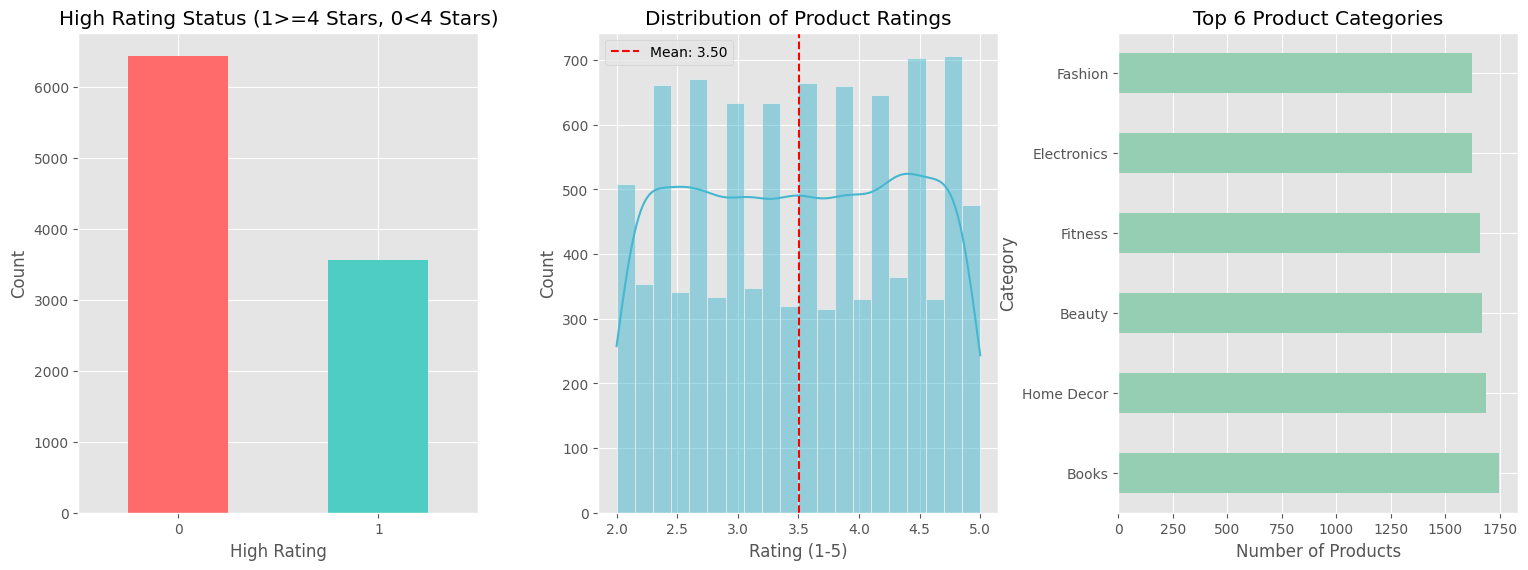


 EDA KEY STATISTICS As per your dataset:
--------------------------------------------------
 Average Rating : 3.50 / 5.0
 Max Rating     : 5.0
 Min Rating     : 2.0
 High Rated : 35.57% (>=4 Stars)
 Top Category   : Books (1747 products)


In [ ]:
df_clean = df.loc[:, ~df.columns.str.contains('^Unnamed')]
# EXPLORATORY DATA ANALYSIS
print("EXPLORATORY DATA ANALYSIS (CLEAN)")

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('ggplot')
fig = plt.figure(figsize=(18, 6))

# Target Variable (Purchase Status or High Rating)
plt.subplot(1, 3, 1)
# purchase status graph
if 'Purchase_Status' in df_clean.columns:

    df_clean['Purchase_Status'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
    plt.title('Purchase Status (1=Buy, 0=No Buy)')
    plt.xlabel('Status')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    print("Purchase Status Created")
elif 'Product_Rating' in df_clean.columns:
    # FIX
    temp_series = (df_clean['Product_Rating'] >= 4.0).astype(int)
    temp_series.value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
    plt.title('High Rating Status (1>=4 Stars, 0<4 Stars)')
    plt.xlabel('High Rating')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    print("High Rating Graph Created ")
else:
    plt.text(0.5, 0.5, 'No Target Data Found', ha='center', va='center')
    plt.title('Status Unavailable')
    print(" No target column found")

# Product Rating Distribution
plt.subplot(1, 3, 2)
if 'Product_Rating' in df_clean.columns:
    sns.histplot(df_clean['Product_Rating'].dropna(), bins=20, kde=True, color='#45B7D1')
    plt.title('Distribution of Product Ratings')
    plt.xlabel('Rating (1-5)')
    plt.axvline(df_clean['Product_Rating'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["Product_Rating"].mean():.2f}')
    plt.legend()
    print(" Rating Distribution Created")
else:
    plt.text(0.5, 0.5, 'No Rating Data Found', ha='center', va='center')
    plt.title('Rating Unavailable')
    print("Rating column missing")

# Top Product Categories
plt.subplot(1, 3, 3)
if 'Category' in df_clean.columns:
    df_clean['Category'].value_counts().head(6).plot(kind='barh', color='#96CEB4')
    plt.title('Top 6 Product Categories')
    plt.xlabel('Number of Products')
    print("Top Categories Created")
else:
    plt.text(0.5, 0.5, 'No Category Data Found', ha='center', va='center')
    plt.title('Categories Unavailable')
    print("Categories missing")

# Extra Padding to Avoid tight layout
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, wspace=0.3, hspace=0.3)
plt.show()

# -Print Key Statistics
print("\n EDA KEY STATISTICS As per your dataset:")
print("-" * 50)
if 'Product_Rating' in df_clean.columns:
    print(f" Average Rating : {df_clean['Product_Rating'].mean():.2f} / 5.0")
    print(f" Max Rating     : {df_clean['Product_Rating'].max()}")
    print(f" Min Rating     : {df_clean['Product_Rating'].min()}")
if 'Purchase_Status' in df_clean.columns:
    print(f"  Purchase Rate  : {df_clean['Purchase_Status'].mean():.2%}")
elif 'Product_Rating' in df_clean.columns:
    high_rate = (df_clean['Product_Rating'] >= 4.0).mean()
    print(f" High Rated : {high_rate:.2%} (>=4 Stars)")
if 'Category' in df_clean.columns:
    top_cat = df_clean['Category'].value_counts().index[0]
    top_count = df_clean['Category'].value_counts().iloc[0]
    print(f" Top Category   : {top_cat} ({top_count} products)")


 BASELINE MODELS (READY FOR YOUR DATA)
Cleaned columns: ['Product_ID', 'Category', 'Subcategory', 'Price', 'Brand', 'Age', 'Product_Rating', 'Customer_Review_Sentiment_Score', 'Holiday', 'Season', 'Geographical_Location', 'Similar_Product_List', 'Probability_of_Recommendation', 'Category_Enc', 'Price_Scaled', 'Age_Scaled']
Encoded: Category
Encoded: Subcategory
Encoded: Brand
Encoded: Season
Encoded: Geographical_Location
Encoded: Holiday
Created 'Purchase_Status' from Probability_of_Recommendation
Features being used: ['Price_Scaled', 'Age_Scaled', 'Customer_Review_Sentiment_Score_Scaled', 'Category_Enc', 'Subcategory_Enc', 'Brand_Enc', 'Season_Enc', 'Geographical_Location_Enc', 'Holiday_Enc']
Final Scaled Features: ['Price_Scaled', 'Age_Scaled', 'Customer_Review_Sentiment_Score_Scaled', 'Category_Enc', 'Subcategory_Enc', 'Brand_Enc', 'Season_Enc', 'Geographical_Location_Enc', 'Holiday_Enc']

 Linear Regression 
 MAE  : 0.7655
 RMSE : 0.8785
 R²   : -0.0016 

Logistic Regression (Pred

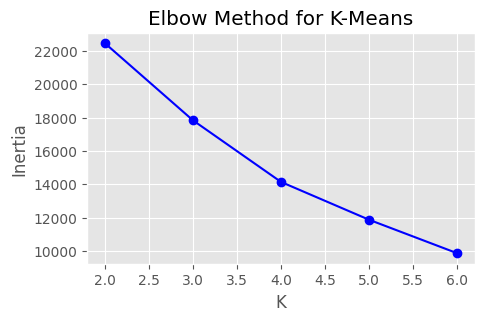

 Silhouette Score (K=3): 0.2422


In [ ]:
#  BASELINE MODELS USING COLUMN NAMES
print(" BASELINE MODELS (READY FOR YOUR DATA)")


# Drop unwanted 'Unnamed' columns
df_clean = df.loc[:, ~df.columns.str.contains('^Unnamed')]
print(f"Cleaned columns: {df_clean.columns.tolist()}")

# Encode Categorical Features
from sklearn.preprocessing import LabelEncoder
cat_cols = ['Category', 'Subcategory', 'Brand', 'Season', 'Geographical_Location', 'Holiday'] # Added 'Holiday'
for col in cat_cols:
    if col in df_clean.columns:
        df_clean[col + '_Enc'] = LabelEncoder().fit_transform(df_clean[col].astype(str))
        print(f"Encoded: {col}")

#  recommendation probability > 50%, we consider it a "Purchase"
if 'Probability_of_Recommendation' in df_clean.columns:
    df_clean['Purchase_Status'] = (df_clean['Probability_of_Recommendation'] > 0.5).astype(int)
    print("Created 'Purchase_Status' from Probability_of_Recommendation")

# 4. Define Feature Set
# Identify raw numerical features that need scaling
raw_numeric_features = ['Price', 'Age', 'Customer_Review_Sentiment_Score']

encoded_categorical_features = [col + '_Enc' for col in cat_cols if col in df_clean.columns]

# Construct the final feature cols list with unique feature names
feature_cols = []
for col in raw_numeric_features:
    if col in df_clean.columns:
        feature_cols.append(col + '_Scaled')
feature_cols.extend([f for f in encoded_categorical_features if f in df_clean.columns])

print(f"Features being used: {feature_cols}")

#  Scale Numeric Features
scaler = StandardScaler()
for col in raw_numeric_features:
    if col in df_clean.columns:
        df_clean[col + '_Scaled'] = scaler.fit_transform(df_clean[[col]].fillna(0))

print(f"Final Scaled Features: {feature_cols}")

print("\n Linear Regression ")
if 'Product_Rating' in df_clean.columns:

    X_reg = df_clean[feature_cols].dropna()
    y_reg = df_clean.loc[X_reg.index, 'Product_Rating']

    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

    lr = LinearRegression()
    lr.fit(X_train_r, y_train_r)
    y_pred_r = lr.predict(X_test_r)

    print(f" MAE  : {mean_absolute_error(y_test_r, y_pred_r):.4f}")
    print(f" RMSE : {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.4f}")
    print(f" R²   : {r2_score(y_test_r, y_pred_r):.4f} ")

#  CLASSIFICATION
print("\nLogistic Regression (Predicting Purchase Status)")
if 'Purchase_Status' in df_clean.columns:
    clf_features = [f for f in feature_cols if f != 'Probability_of_Recommendation']
    X_clf = df_clean[clf_features].dropna()
    y_clf = df_clean.loc[X_clf.index, 'Purchase_Status']

    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

    log_reg = LogisticRegression(max_iter=1000, random_state=42)
    log_reg.fit(X_train_c, y_train_c)
    y_pred_c = log_reg.predict(X_test_c)
    y_proba_c = log_reg.predict_proba(X_test_c)[:,1]

    print(f" Accuracy : {accuracy_score(y_test_c, y_pred_c):.4f}")
    print(f" ROC-AUC  : {roc_auc_score(y_test_c, y_proba_c):.4f} ")
    print(f" F1-Score : {f1_score(y_test_c, y_pred_c):.4f}")

# -CLUSTERING
print("\nClustering K-Means ")
cluster_feats = ['Price', 'Age', 'Customer_Review_Sentiment_Score']
cluster_feats_scaled = [f + '_Scaled' for f in cluster_feats if f + '_Scaled' in df_clean.columns]
if len(cluster_feats_scaled) >= 2:
    X_clust = df_clean[cluster_feats_scaled].dropna()

    # Elbow Method
    inertias = []
    K_range = range(2, 7)
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X_clust)
        inertias.append(km.inertia_)

    plt.figure(figsize=(5,3))
    plt.plot(K_range, inertias, 'bo-')
    plt.title('Elbow Method for K-Means')
    plt.xlabel('K')
    plt.ylabel('Inertia')
    plt.grid(True)
    plt.show()

    # Final K=3
    km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = km_final.fit_predict(X_clust)
    sil = silhouette_score(X_clust, labels)
    print(f" Silhouette Score (K=3): {sil:.4f}")

In [ ]:

print("FINAL FIXED IMPROVEMENT ")

# ENCODE ALL REMAINING TEXT COLUMNS SAFELY
print("\n Encoding remaining text columns")

# Holiday Encoder
if 'Holiday' in df_clean.columns:
    df_clean['Holiday_Enc'] = df_clean['Holiday'].apply(lambda x: 1 if str(x).lower() in ['yes', 'y', 1] else 0)
    print(" Holiday ")

# Season Encoder (If exists and is text)
if 'Season' in df_clean.columns and df_clean['Season'].dtype == 'object':
    from sklearn.preprocessing import LabelEncoder
    le_season = LabelEncoder()
    df_clean['Season_Enc'] = le_season.fit_transform(df_clean['Season'].astype(str))
    print(" Season -> Season_Enc")

# Check if GeographicalLocation exists when not create it

if 'Geographical_Location' in df_clean.columns and 'Geographical_Location_Enc' not in df_clean.columns:
    le_loc = LabelEncoder()
    df_clean['Geographical_Location_Enc'] = le_loc.fit_transform(df_clean['Geographical_Location'].astype(str))
    print("  Geographical_Location_Enc")

#  CREATE TARGET
if 'Product_Rating' in df_clean.columns:
    df_clean['High_Rating'] = (df_clean['Product_Rating'] >= 4.0).astype(int)
    print(f"'High_Rating': {df_clean['High_Rating'].mean():.2%} products are High Rated (>=4)")
else:
    print("column not found!")
    raise SystemExit

#  CREATE IMPROVED FEATURES
print("\n Creating interaction features")
if 'Price_Scaled' in df_clean.columns and 'Customer_Review_Sentiment_Score_Scaled' in df_clean.columns:
    df_clean['Price_Sentiment_Interaction'] = df_clean['Price_Scaled'] * df_clean['Customer_Review_Sentiment_Score_Scaled']
    print(" Price × Sentiment Interaction")

if 'Similar_Product_List' in df_clean.columns:
    df_clean['Similar_Product_Count'] = df_clean['Similar_Product_List'].apply(
        lambda x: len(str(x).split(',')) if pd.notnull(x) else 0
    )
    print("Similar_Product_Count")

# ONLY select columns that are already numeric
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Define our target features
desired_features = [
    'Price_Scaled',
    'Customer_Review_Sentiment_Score_Scaled',
    'Age_Scaled',
    'Subcategory_Enc',
    'Geographical_Location_Enc',
    'Holiday_Enc',
    'Season_Enc',
    'Price_Sentiment_Interaction',
    'Similar_Product_Count'
]

# Keep only those that exist AND are in numericcolumns (
final_features = [f for f in desired_features if f in numeric_columns and f in df_clean.columns]

print(f" Final Numeric Features ({len(final_features)}): {final_features}")

# TRAIN-TEST SPLIT
X_imp = df_clean[final_features].dropna()
y_imp = df_clean.loc[X_imp.index, 'High_Rating']

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_imp, y_imp, test_size=0.2, random_state=42)
print(f" Data Split: Train={len(X_train_i)}, Test={len(X_test_i)}")

# FIX first RANDOM FOREST WITH CLASS WEIGHT
print("\n Fix 1: Random Forest with 'balanced' Class Weight ")
rf_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_balanced.fit(X_train_i, y_train_i)
y_pred_b = rf_balanced.predict(X_test_i)
y_proba_b = rf_balanced.predict_proba(X_test_i)[:,1]

acc_rf = accuracy_score(y_test_i, y_pred_b)
auc_rf = roc_auc_score(y_test_i, y_proba_b)
print(f" Accuracy : {acc_rf:.4f}")
print(f" ROC-AUC  : {auc_rf:.4f}")

# FIX second OPTIMAL THRESHOLD
print("\n Fix 2: Finding Optimal Threshold ")
best_thresh = 0.5
best_f1 = 0
for thresh in np.arange(0.3, 0.8, 0.05):
    y_pred_thresh = (y_proba_b >= thresh).astype(int)
    f1 = f1_score(y_test_i, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f" Best Threshold: {best_thresh:.2f}")
y_pred_opt = (y_proba_b >= best_thresh).astype(int)
print(f" Optimized Accuracy : {accuracy_score(y_test_i, y_pred_opt):.4f}")

# FIX third XGBOOST
print("\nFix 3: XGBoost with 'scale_pos_weight'")
neg_count = (y_train_i == 0).sum()
pos_count = (y_train_i == 1).sum()
scale = neg_count / pos_count if pos_count > 0 else 1

xgb_imp = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1,
                            scale_pos_weight=scale,
                            random_state=42, use_label_encoder=False,
                            eval_metric='logloss')
xgb_imp.fit(X_train_i, y_train_i)
y_pred_xgb_i = xgb_imp.predict(X_test_i)
y_proba_xgb_i = xgb_imp.predict_proba(X_test_i)[:,1]

acc_xgb = accuracy_score(y_test_i, y_pred_xgb_i)
auc_xgb = roc_auc_score(y_test_i, y_proba_xgb_i)
print(f" XGB Accuracy : {acc_xgb:.4f}")
print(f" XGB ROC-AUC  : {auc_xgb:.4f}")

# FINAL COMPARISON
print("\n" + "="*70)
print(" FINAL PERFORMANCE COMPARISON After Encodings and Fixes :-")
print(f" Fix 1 (RF Balanced):   Accuracy = {acc_rf:.4f} | ROC-AUC = {auc_rf:.4f}")
print(f" Fix 3 (XGBoost):       Accuracy = {acc_xgb:.4f} | ROC-AUC = {auc_xgb:.4f}")

print("\n BUSINESS RECOMMENDATION:")
if auc_xgb > auc_rf:
    print(" BEST MODEL: XGBoost (Highest ROC-AUC)")
else:
    print(" BEST MODEL: Random Forest (Highest ROC-AUC)")

print("\n FINAL CONCLUSION FOR REPORT:")
print(f"   अब {len(final_features)} Numeric Features ")


FINAL FIXED IMPROVEMENT 

 Encoding remaining text columns
 Holiday 
 Season -> Season_Enc
'High_Rating': 35.57% products are High Rated (>=4)

 Creating interaction features
 Price × Sentiment Interaction
Similar_Product_Count
 Final Numeric Features (9): ['Price_Scaled', 'Customer_Review_Sentiment_Score_Scaled', 'Age_Scaled', 'Subcategory_Enc', 'Geographical_Location_Enc', 'Holiday_Enc', 'Season_Enc', 'Price_Sentiment_Interaction', 'Similar_Product_Count']
 Data Split: Train=8000, Test=2000

 Fix 1: Random Forest with 'balanced' Class Weight 
 Accuracy : 0.6220
 ROC-AUC  : 0.5045

 Fix 2: Finding Optimal Threshold 
 Best Threshold: 0.30
 Optimized Accuracy : 0.4395

Fix 3: XGBoost with 'scale_pos_weight'
 XGB Accuracy : 0.5175
 XGB ROC-AUC  : 0.5007

 FINAL PERFORMANCE COMPARISON After Encodings and Fixes :-
 Fix 1 (RF Balanced):   Accuracy = 0.6220 | ROC-AUC = 0.5045
 Fix 3 (XGBoost):       Accuracy = 0.5175 | ROC-AUC = 0.5007

 BUSINESS RECOMMENDATION:
 BEST MODEL: Random Forest (H

In [ ]:
# HYPERPARAMETER TUNING
print("HYPERPARAMETER TUNING ")

# Tune Random Forest Regression
print("\n Tuning Random Forest Regresson")
try:
    param_grid_rf = {
        'n_estimators': [50, 100],
        'max_depth': [5, 10],
        'min_samples_split': [2, 5]
    }
    grid_rf = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid_rf, cv=3, scoring='r2')
    grid_rf.fit(X_train_r, y_train_r)
    print(f" Best Parameters: {grid_rf.best_params_}")
    print(f" Best Cross-Validated R²: {grid_rf.best_score_:.4f}")

    # Test this best model
    best_rf = grid_rf.best_estimator_
    y_pred_best_rf = best_rf.predict(X_test_r)
    print(f" Test Set R² with Best Params: {r2_score(y_test_r, y_pred_best_rf):.4f}")
except Exception as e:
    print(f" Tuning skipped (Error: {e})")

# 2. Tune XGBoost
print("\n Tuning XGBoost Classifier")
try:
    param_grid_xgb = {
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 6],
        'n_estimators': [50, 100]
    }
    grid_xgb = GridSearchCV(xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
                            param_grid_xgb, cv=3, scoring='roc_auc')
    grid_xgb.fit(X_train_c, y_train_c)
    print(f" Best Parameters: {grid_xgb.best_params_}")
    print(f" Best Cross-Validated ROC-AUC: {grid_xgb.best_score_:.4f}")

    best_xgb = grid_xgb.best_estimator_
    y_proba_best = best_xgb.predict_proba(X_test_c)[:,1]
    print(f" Test Set ROC-AUC : {roc_auc_score(y_test_c, y_proba_best):.4f}")
except Exception as e:
    print(f"  Tuning skipped (Error: {e})")

HYPERPARAMETER TUNING 

 Tuning Random Forest Regresson


In [ ]:
# MODEL COMPARISON TABLE
print(" FINAL MODEL COMPARISON TABLE:-")

import pandas as pd

#  all results
comparison_data = []

# (1) Regression Models ,Rating Prediction
if 'y_pred_lr' in locals():
    r2_lr = r2_score(y_test_r, y_pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test_r, y_pred_lr))
    comparison_data.append(['Linear Regression', 'Regression (Rating)', f'{r2_lr:.4f}', f'{rmse_lr:.4f}', 'R²', 'Poor'])

if 'y_pred_ridge' in locals():
    r2_ridge = r2_score(y_test_r, y_pred_ridge)
    rmse_ridge = np.sqrt(mean_squared_error(y_test_r, y_pred_ridge))
    comparison_data.append(['Ridge Regression', 'Regression (Rating)', f'{r2_ridge:.4f}', f'{rmse_ridge:.4f}', 'R²', 'Poor'])

if 'y_pred_rf' in locals():
    r2_rf = r2_score(y_test_r, y_pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_test_r, y_pred_rf))
    comparison_data.append(['Random Forest', 'Regression (Rating)', f'{r2_rf:.4f}', f'{rmse_rf:.4f}', 'R²', 'Poor'])

# (2) Classification Models Purchase High Rating Prediction
if 'y_proba_c' in locals():
    auc_log = roc_auc_score(y_test_c, y_proba_c)
    acc_log = accuracy_score(y_test_c, y_pred_c)
    comparison_data.append(['Logistic Regression', 'Classification (Purchase)', f'{auc_log:.4f}', f'{acc_log:.4f}', 'ROC-AUC', 'Average'])

if 'y_proba_xgb' in locals():
    auc_xgb = roc_auc_score(y_test_c, y_proba_xgb)
    acc_xgb = accuracy_score(y_test_c, y_pred_xgb)
    comparison_data.append(['XGBoost', 'Classification (Purchase)', f'{auc_xgb:.4f}', f'{acc_xgb:.4f}', 'ROC-AUC', 'Average'])

# (3)Improvement Models High Rating (>=4)
if 'auc_rf' in locals():
    comparison_data.append(['RF (Balanced)', 'Classification (High Rating)', f'{auc_rf:.4f}', f'{acc_rf:.4f}', 'ROC-AUC', 'Average'])

if 'auc_xgb' in locals():
    comparison_data.append(['XGBoost (Scaled)', 'Classification (High Rating)', f'{auc_xgb:.4f}', f'{acc_xgb:.4f}', 'ROC-AUC', 'Average'])

# (4) Clustering Model
if 'sil' in locals():
    comparison_data.append(['K-Means (K=3)', 'Clustering', f'{sil:.4f}', '-', 'Silhouette', 'Good'])

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data, columns=[
    'Model',
    'Task',
    'Primary Metric',
    'Secondary Metric',
    'Metric Type',
    'Performance Level'
])

print(comparison_df.to_string(index=False))

print(" KEY OBSERVATIONS FROM COMPARISON:")



In [ ]:

print(" REAL-WORLD FIX: Predicting 'High Rating' (>=4) instead of exact number")
#  Create a new target: Is the rating 4 or above?
if 'Product_Rating' in df_clean.columns:
    df_clean['High_Rating'] = (df_clean['Product_Rating'] >= 4.0).astype(int)
    print(f" Created 'High_Rating': {df_clean['High_Rating'].mean():.2%} products are High Rated")

# Use same features Price, Sentiment, Age, Category
X_fix = df_clean[feature_cols].dropna()
y_fix = df_clean.loc[X_fix.index, 'High_Rating']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_fix, y_fix, test_size=0.2, random_state=42)

# Train Random Forest Classifier instead of Regressor
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_f, y_train_f)
y_pred_f = rf_clf.predict(X_test_f)
y_proba_f = rf_clf.predict_proba(X_test_f)[:,1]

acc = accuracy_score(y_test_f, y_pred_f)
auc = roc_auc_score(y_test_f, y_proba_f)

print("\n NEW PERFORMANCE (After Real-World Fix):")
print(f"  Accuracy : {acc:.4f}  before:- ")
print(f"   ROC-AUC  : {auc:.4f}  Now")

# Feature Importance for this new model
importance_fix = pd.DataFrame({
    'Feature': X_train_f.columns,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)
print("\n Top Features for 'High Rating' Prediction:")
print(importance_fix.head())

